# Airbnb New User Booking Conversion Analysis

## 1. Project Background

In [157]:
import pandas as pd
import numpy as np
from pathlib import Path

paths = {
    "age_gender": Path(r"D:\age_gender_bkts.csv\age_gender_bkts.csv"),
    "countries": Path(r"D:\countries.csv\countries.csv"),
    "sessions": Path(r"D:\sessions.csv\sessions.csv"),
    "train": Path(r"D:\train_users_2.csv\train_users_2.csv"),
    "test": Path(r"D:\test_users.csv\test_users.csv"),
    "sample_submission": Path(r"D:\sample_submission_NDF.csv\sample_submission_NDF.csv")
}


for name, path in paths.items():
    print(name, "exist" if path.exists() else "not exist", path)

age_gender exist D:\age_gender_bkts.csv\age_gender_bkts.csv
countries exist D:\countries.csv\countries.csv
sessions exist D:\sessions.csv\sessions.csv
train exist D:\train_users_2.csv\train_users_2.csv
test exist D:\test_users.csv\test_users.csv
sample_submission exist D:\sample_submission_NDF.csv\sample_submission_NDF.csv


## 2. Data Loading

In [2]:
train = pd.read_csv(paths["train"])
test = pd.read_csv(paths["test"])
sessions = pd.read_csv(paths["sessions"])
countries = pd.read_csv(paths["countries"])
age_gender = pd.read_csv(paths["age_gender"])
sample_submission = pd.read_csv(paths["sample_submission"])

print("train:", train.shape)
print("test:", test.shape)
print("sessions:", sessions.shape)
print("countries:", countries.shape)
print("age_gender:", age_gender.shape)
print("sample_submission:", sample_submission.shape)

train: (213451, 16)
test: (62096, 15)
sessions: (10567737, 6)
countries: (10, 7)
age_gender: (420, 5)
sample_submission: (62096, 2)


In [3]:
train.head()

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
0,gxn3p5htnn,2010-06-28,20090319043255,NaN,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF
1,820tgsjxq7,2011-05-25,20090523174809,NaN,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,2010-09-14,20091208061105,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US


In [4]:
sessions.head()

,user_id,action,action_type,action_detail,device_type,secs_elapsed
0,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,319.0
1,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,67753.0
2,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,301.0
3,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,22141.0
4,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,435.0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213451 entries, 0 to 213450
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       213451 non-null  object 
 1   date_account_created     213451 non-null  object 
 2   timestamp_first_active   213451 non-null  int64  
 3   date_first_booking       88908 non-null   object 
 4   gender                   213451 non-null  object 
 5   age                      125461 non-null  float64
 6   signup_method            213451 non-null  object 
 7   signup_flow              213451 non-null  int64  
 8   language                 213451 non-null  object 
 9   affiliate_channel        213451 non-null  object 
 10  affiliate_provider       213451 non-null  object 
 11  first_affiliate_tracked  207386 non-null  object 
 12  signup_app               213451 non-null  object 
 13  first_device_type        213451 non-null  object 
 14  firs

In [6]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10567737 entries, 0 to 10567736
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   user_id        object 
 1   action         object 
 2   action_type    object 
 3   action_detail  object 
 4   device_type    object 
 5   secs_elapsed   float64
dtypes: float64(1), object(5)
memory usage: 483.8+ MB


In [7]:
train.isnull().sum().sort_values(ascending=False)

date_first_booking         124543
age                         87990
first_affiliate_tracked      6065
id                              0
date_account_created            0
timestamp_first_active          0
gender                          0
signup_method                   0
signup_flow                     0
language                        0
affiliate_channel               0
affiliate_provider              0
signup_app                      0
first_device_type               0
first_browser                   0
country_destination             0
dtype: int64

In [8]:
sessions.isnull().sum().sort_values(ascending=False)

action_type      1126204
action_detail    1126204
secs_elapsed      136031
action             79626
user_id            34496
device_type            0
dtype: int64

In [9]:
train["country_destination"].value_counts()

country_destination
NDF      124543
US        62376
other     10094
FR         5023
IT         2835
GB         2324
ES         2249
CA         1428
DE         1061
NL          762
AU          539
PT          217
Name: count, dtype: int64

In [10]:
train["country_destination"].value_counts(normalize=True)

country_destination
NDF      0.583473
US       0.292226
other    0.047290
FR       0.023532
IT       0.013282
GB       0.010888
ES       0.010536
CA       0.006690
DE       0.004971
NL       0.003570
AU       0.002525
PT       0.001017
Name: proportion, dtype: float64

## 2. Data Loading

In [23]:
train_clean = train.copy()
sessions_clean = sessions.copy()

In [25]:
# 账户创建日期
train_clean["date_account_created"] = pd.to_datetime(
    train_clean["date_account_created"], 
    errors="coerce"
)

# 首次预订日期
train_clean["date_first_booking"] = pd.to_datetime(
    train_clean["date_first_booking"], 
    errors="coerce"
)

# 首次活跃时间，原始格式是 20140101000936 这种数字
train_clean["timestamp_first_active"] = pd.to_datetime(
    train_clean["timestamp_first_active"].astype(str),
    format="%Y%m%d%H%M%S",
    errors="coerce"
)

# 提取注册年月，后面做用户增长趋势
train_clean["account_created_year"] = train_clean["date_account_created"].dt.year
train_clean["account_created_month"] = train_clean["date_account_created"].dt.month
train_clean["account_created_year_month"] = train_clean["date_account_created"].dt.to_period("M").astype(str)

In [27]:
# 是否完成首次预订：NDF = No Destination Found，也就是没有预订
train_clean["is_booked"] = np.where(train_clean["country_destination"] == "NDF", 0, 1)

train_clean["is_booked"].value_counts()

is_booked
0    124543
1     88908
Name: count, dtype: int64

In [29]:
train_clean["is_booked"].value_counts(normalize=True)

is_booked
0    0.583473
1    0.416527
Name: proportion, dtype: float64

In [31]:
train_clean["gender"].value_counts()

gender
-unknown-    95688
FEMALE       63041
MALE         54440
OTHER          282
Name: count, dtype: int64

In [33]:
train_clean["gender_clean"] = train_clean["gender"].replace("-unknown-", "UNKNOWN")
train_clean["gender_clean"].value_counts()

gender_clean
UNKNOWN    95688
FEMALE     63041
MALE       54440
OTHER        282
Name: count, dtype: int64

In [35]:
train_clean["age"].describe()

count    125461.000000
mean         49.668335
std         155.666612
min           1.000000
25%          28.000000
50%          34.000000
75%          43.000000
max        2014.000000
Name: age, dtype: float64

In [37]:
# 复制年龄字段
train_clean["age_clean"] = train_clean["age"]

# 如果年龄大于 1000，可能是出生年份，例如 1988、1992
# 用 2014 减去出生年份，得到年龄
train_clean.loc[train_clean["age_clean"] > 1000, "age_clean"] = (
    2014 - train_clean.loc[train_clean["age_clean"] > 1000, "age_clean"]
)

# 将明显不合理的年龄设为空值
train_clean.loc[
    (train_clean["age_clean"] < 15) | (train_clean["age_clean"] > 90),
    "age_clean"
] = np.nan

train_clean["age_clean"].describe()

count    122890.000000
mean         36.473236
std          11.472324
min          15.000000
25%          28.000000
50%          34.000000
75%          42.000000
max          90.000000
Name: age_clean, dtype: float64

In [39]:
age_bins = [15, 24, 34, 44, 54, 64, 90]
age_labels = ["15-24", "25-34", "35-44", "45-54", "55-64", "65+"]

train_clean["age_group"] = pd.cut(
    train_clean["age_clean"],
    bins=age_bins,
    labels=age_labels,
    right=True
)

train_clean["age_group"] = train_clean["age_group"].astype("object").fillna("UNKNOWN")

train_clean["age_group"].value_counts()

age_group
UNKNOWN    90569
25-34      55694
35-44      30759
45-54      14521
15-24      10771
55-64       7601
65+         3536
Name: count, dtype: int64

In [41]:
train_clean["first_affiliate_tracked"] = train_clean["first_affiliate_tracked"].fillna("untracked")

In [43]:
# 删除没有 user_id 的行为记录，因为无法和用户表关联
sessions_clean = sessions_clean.dropna(subset=["user_id"]).copy()

# 行为字段缺失填充
sessions_clean["action"] = sessions_clean["action"].fillna("missing")
sessions_clean["action_type"] = sessions_clean["action_type"].fillna("missing")
sessions_clean["action_detail"] = sessions_clean["action_detail"].fillna("missing")

# 停留时间缺失填 0
sessions_clean["secs_elapsed"] = sessions_clean["secs_elapsed"].fillna(0)

In [45]:
sessions_clean["action_detail"].value_counts().head(30)

action_detail
view_search_results            1771026
p3                             1371626
missing                        1122957
-unknown-                      1028222
wishlist_content_update         704782
user_profile                    654626
change_trip_characteristics     486414
similar_listings                363423
user_social_connections         335577
listing_reviews                 267991
update_listing                  267776
dashboard                       152515
user_wishlists                  152260
header_userpic                  141315
message_thread                  132199
edit_profile                    108531
message_post                     86925
contact_host                     80872
unavailable_dates                77475
confirm_email_link               58253
create_user                      54611
change_contact_host_dates        52426
user_profile_content_update      50353
user_reviews                     49424
p5                               48155
login      

In [47]:
sessions_clean["action_type"].value_counts().head(20)

action_type
view                3549375
data                2096655
click               1990058
missing             1122957
-unknown-           1028251
submit               620063
message_post          86925
partner_callback      19053
booking_request       18762
modify                 1138
booking_response          4
Name: count, dtype: int64

In [49]:
sessions_clean["device_type"].value_counts().head(20)

device_type
Mac Desktop                         3585886
Windows Desktop                     2648521
iPhone                              2096749
Android Phone                        835991
iPad Tablet                          681836
Android App Unknown Phone/Tablet     272820
-unknown-                            210059
Tablet                               139859
Linux Desktop                         27968
Chromebook                            22272
iPodtouch                              8186
Windows Phone                          2047
Blackberry                              979
Opera Phone                              68
Name: count, dtype: int64

In [53]:
#构建用户级行为特征
session_features = sessions_clean.groupby("user_id").agg(
    session_count=("user_id", "count"),
    total_secs_elapsed=("secs_elapsed", "sum"),
    mean_secs_elapsed=("secs_elapsed", "mean"),
    max_secs_elapsed=("secs_elapsed", "max"),
    unique_action_count=("action", "nunique"),
    unique_action_type_count=("action_type", "nunique"),
    unique_action_detail_count=("action_detail", "nunique"),
    unique_device_count=("device_type", "nunique")
).reset_index()

session_features.head()

,user_id,session_count,total_secs_elapsed,mean_secs_elapsed,max_secs_elapsed,unique_action_count,unique_action_type_count,unique_action_detail_count,unique_device_count
0,00023iyk9l,40,867896.0,21697.400000,567165.0,14,7,14,2
1,0010k6l0om,63,586543.0,9310.206349,127898.0,11,6,9,1
2,001wyh0pz8,90,282965.0,3144.055556,50548.0,10,6,10,1
3,0028jgx1x1,31,297010.0,9580.967742,84636.0,5,5,6,2
4,002qnbzfs5,789,6487080.0,8221.901141,1418284.0,26,8,23,2


In [55]:
session_features.shape

(135483, 9)

In [57]:
# 搜索结果浏览次数
search_result_count = sessions_clean[
    sessions_clean["action_detail"] == "view_search_results"
].groupby("user_id").size().reset_index(name="view_search_results_count")

# 房源详情浏览次数
p3_count = sessions_clean[
    sessions_clean["action_detail"] == "p3"
].groupby("user_id").size().reset_index(name="p3_view_count")

# 预订相关行为
reservation_count = sessions_clean[
    sessions_clean["action_detail"] == "reservations"
].groupby("user_id").size().reset_index(name="reservation_action_count")

# 支付相关行为
payment_count = sessions_clean[
    sessions_clean["action_detail"] == "payment_instruments"
].groupby("user_id").size().reset_index(name="payment_action_count")

In [59]:
session_features = session_features.merge(search_result_count, on="user_id", how="left")
session_features = session_features.merge(p3_count, on="user_id", how="left")
session_features = session_features.merge(reservation_count, on="user_id", how="left")
session_features = session_features.merge(payment_count, on="user_id", how="left")

# 缺失填 0
for col in [
    "view_search_results_count", 
    "p3_view_count", 
    "reservation_action_count", 
    "payment_action_count"
]:
    session_features[col] = session_features[col].fillna(0)

session_features.head()

,user_id,session_count,total_secs_elapsed,mean_secs_elapsed,max_secs_elapsed,unique_action_count,unique_action_type_count,unique_action_detail_count,unique_device_count,view_search_results_count,p3_view_count,reservation_action_count,payment_action_count
0,00023iyk9l,40,867896.0,21697.400000,567165.0,14,7,14,2,5.0,6.0,0.0,0.0
1,0010k6l0om,63,586543.0,9310.206349,127898.0,11,6,9,1,10.0,13.0,0.0,0.0
2,001wyh0pz8,90,282965.0,3144.055556,50548.0,10,6,10,1,66.0,2.0,0.0,0.0
3,0028jgx1x1,31,297010.0,9580.967742,84636.0,5,5,6,2,9.0,9.0,0.0,0.0
4,002qnbzfs5,789,6487080.0,8221.901141,1418284.0,26,8,23,2,125.0,25.0,20.0,12.0


## 4. Feature Engineering

In [63]:
#将用户注册表和用户行为特征表合并
user_features = train_clean.merge(
    session_features,
    left_on="id",
    right_on="user_id",
    how="left"
)

print(user_features.shape)
user_features.head()

(213451, 36)


,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,...,mean_secs_elapsed,max_secs_elapsed,unique_action_count,unique_action_type_count,unique_action_detail_count,unique_device_count,view_search_results_count,p3_view_count,reservation_action_count,payment_action_count
0,gxn3p5htnn,2010-06-28,2009-03-19 04:32:55,NaT,-unknown-,NaN,facebook,0,en,direct,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,820tgsjxq7,2011-05-25,2009-05-23 17:48:09,NaT,MALE,38.0,facebook,0,en,seo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4ft3gnwmtx,2010-09-28,2009-06-09 23:12:47,2010-08-02,FEMALE,56.0,basic,3,en,direct,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bjjt8pjhuk,2011-12-05,2009-10-31 06:01:29,2012-09-08,FEMALE,42.0,facebook,0,en,direct,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,87mebub9p4,2010-09-14,2009-12-08 06:11:05,2010-02-18,-unknown-,41.0,basic,0,en,direct,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
session_cols = [
    "session_count",
    "total_secs_elapsed",
    "mean_secs_elapsed",
    "max_secs_elapsed",
    "unique_action_count",
    "unique_action_type_count",
    "unique_action_detail_count",
    "unique_device_count",
    "view_search_results_count",
    "p3_view_count",
    "reservation_action_count",
    "payment_action_count"
]

user_features[session_cols] = user_features[session_cols].fillna(0)

In [67]:
user_features[[
    "id",
    "country_destination",
    "is_booked",
    "gender_clean",
    "age_group",
    "affiliate_channel",
    "affiliate_provider",
    "first_device_type",
    "session_count",
    "view_search_results_count",
    "p3_view_count",
    "reservation_action_count",
    "payment_action_count"
]].head()

,id,country_destination,is_booked,gender_clean,age_group,affiliate_channel,affiliate_provider,first_device_type,session_count,view_search_results_count,p3_view_count,reservation_action_count,payment_action_count
0,gxn3p5htnn,NDF,0,UNKNOWN,UNKNOWN,direct,direct,Mac Desktop,0.0,0.0,0.0,0.0,0.0
1,820tgsjxq7,NDF,0,MALE,35-44,seo,google,Mac Desktop,0.0,0.0,0.0,0.0,0.0
2,4ft3gnwmtx,US,1,FEMALE,55-64,direct,direct,Windows Desktop,0.0,0.0,0.0,0.0,0.0
3,bjjt8pjhuk,other,1,FEMALE,35-44,direct,direct,Mac Desktop,0.0,0.0,0.0,0.0,0.0
4,87mebub9p4,US,1,UNKNOWN,35-44,direct,direct,Mac Desktop,0.0,0.0,0.0,0.0,0.0


In [69]:
user_features.to_csv(
    r"D:\airbnb_user_features.csv",
    index=False,
    encoding="utf-8-sig"
)

print("保存成功：D:\\airbnb_user_features.csv")

保存成功：D:\airbnb_user_features.csv


## 5. Exploratory Data Analysis

In [71]:
total_users = len(user_features)
booked_users = user_features["is_booked"].sum()
booking_rate = booked_users / total_users

print("总用户数:", total_users)
print("完成首单预订用户数:", booked_users)
print("首单转化率:", round(booking_rate * 100, 2), "%")

总用户数: 213451
完成首单预订用户数: 88908
首单转化率: 41.65 %


In [73]:
#检查有行为记录的用户比例
user_features["has_session"] = (user_features["session_count"] > 0).astype(int)

user_features["has_session"].value_counts(normalize=True)

has_session
0    0.654183
1    0.345817
Name: proportion, dtype: float64

In [75]:
#有无session的首单转化
user_features.groupby("has_session")["is_booked"].agg(["count", "mean"])

,count,mean
has_session,,
0,139636,0.430648
1,73815,0.389812


In [77]:
#渠道转化率
channel_summary = user_features.groupby("affiliate_channel").agg(
    user_count=("id", "count"),
    booked_users=("is_booked", "sum"),
    booking_rate=("is_booked", "mean")
).reset_index()

channel_summary["booking_rate"] = channel_summary["booking_rate"] * 100

channel_summary = channel_summary.sort_values("user_count", ascending=False)

channel_summary

,affiliate_channel,user_count,booked_users,booking_rate
2,direct,137727,59398,43.127346
5,sem-brand,26045,11094,42.595508
6,sem-non-brand,18844,7150,37.943112
3,other,8961,3600,40.174088
7,seo,8663,3955,45.653931
0,api,8167,2785,34.100649
1,content,3948,558,14.133739
4,remarketing,1096,368,33.576642


In [79]:
#如果看注册人数较多的渠道
channel_summary[channel_summary["user_count"] >= 500].sort_values(
    "booking_rate", 
    ascending=False
)

,affiliate_channel,user_count,booked_users,booking_rate
7,seo,8663,3955,45.653931
2,direct,137727,59398,43.127346
5,sem-brand,26045,11094,42.595508
3,other,8961,3600,40.174088
6,sem-non-brand,18844,7150,37.943112
0,api,8167,2785,34.100649
4,remarketing,1096,368,33.576642
1,content,3948,558,14.133739


In [81]:
#设备转化率
device_summary = user_features.groupby("first_device_type").agg(
    user_count=("id", "count"),
    booked_users=("is_booked", "sum"),
    booking_rate=("is_booked", "mean")
).reset_index()

device_summary["booking_rate"] = device_summary["booking_rate"] * 100

device_summary.sort_values("user_count", ascending=False)

,first_device_type,user_count,booked_users,booking_rate
3,Mac Desktop,89600,42250,47.154018
6,Windows Desktop,72716,30152,41.465427
8,iPhone,20759,6417,30.911894
7,iPad,14339,5464,38.105865
4,Other/Unknown,10667,2875,26.952283
0,Android Phone,2803,715,25.508384
1,Android Tablet,1292,460,35.603715
2,Desktop (Other),1199,550,45.871560
5,SmartPhone (Other),76,25,32.894737


In [83]:
#行为强度和转化率
user_features["session_group"] = pd.cut(
    user_features["session_count"],
    bins=[-1, 0, 5, 20, 50, 100, 500, float("inf")],
    labels=[
        "0次",
        "1-5次",
        "6-20次",
        "21-50次",
        "51-100次",
        "101-500次",
        "500次以上"
    ]
)

session_group_summary = user_features.groupby("session_group").agg(
    user_count=("id", "count"),
    booked_users=("is_booked", "sum"),
    booking_rate=("is_booked", "mean")
).reset_index()

session_group_summary["booking_rate"] = session_group_summary["booking_rate"] * 100

session_group_summary

C:\Users\XuefeiSun\AppData\Local\Temp\ipykernel_3024\1705609968.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_group_summary = user_features.groupby("session_group").agg(


,session_group,user_count,booked_users,booking_rate
0,0次,139636,60134,43.064826
1,1-5次,8318,2391,28.744891
2,6-20次,16877,5735,33.981158
3,21-50次,17947,7257,40.435727
4,51-100次,14099,5965,42.307965
5,101-500次,15674,6941,44.283527
6,500次以上,900,485,53.888889


In [85]:
#行为数据专用数据集
behavior_df = user_features[user_features["has_session"] == 1].copy()

print(behavior_df.shape)
print(behavior_df["is_booked"].mean())

(73815, 38)
0.3898123687597372


In [87]:
#行为活跃度与首单转化关系
behavior_df["session_group"] = pd.cut(
    behavior_df["session_count"],
    bins=[0, 5, 20, 50, 100, 500, float("inf")],
    labels=[
        "1-5次",
        "6-20次",
        "21-50次",
        "51-100次",
        "101-500次",
        "500次以上"
    ],
    include_lowest=True
)

session_group_summary = behavior_df.groupby("session_group").agg(
    user_count=("id", "count"),
    booked_users=("is_booked", "sum"),
    booking_rate=("is_booked", "mean")
).reset_index()

session_group_summary["booking_rate"] = session_group_summary["booking_rate"] * 100

session_group_summary

C:\Users\XuefeiSun\AppData\Local\Temp\ipykernel_3024\351986265.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_group_summary = behavior_df.groupby("session_group").agg(


,session_group,user_count,booked_users,booking_rate
0,1-5次,8318,2391,28.744891
1,6-20次,16877,5735,33.981158
2,21-50次,17947,7257,40.435727
3,51-100次,14099,5965,42.307965
4,101-500次,15674,6941,44.283527
5,500次以上,900,485,53.888889


### 5.1 Overall Booking Conversion

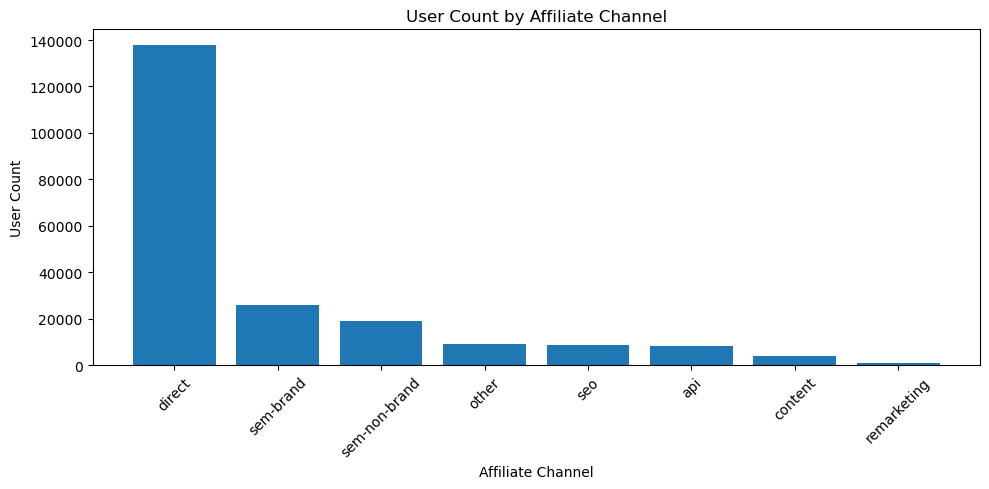

In [89]:
import matplotlib.pyplot as plt

channel_plot = channel_summary.sort_values("user_count", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(channel_plot["affiliate_channel"], channel_plot["user_count"])
plt.title("User Count by Affiliate Channel")
plt.xlabel("Affiliate Channel")
plt.ylabel("User Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.2 Channel Conversion Analysis

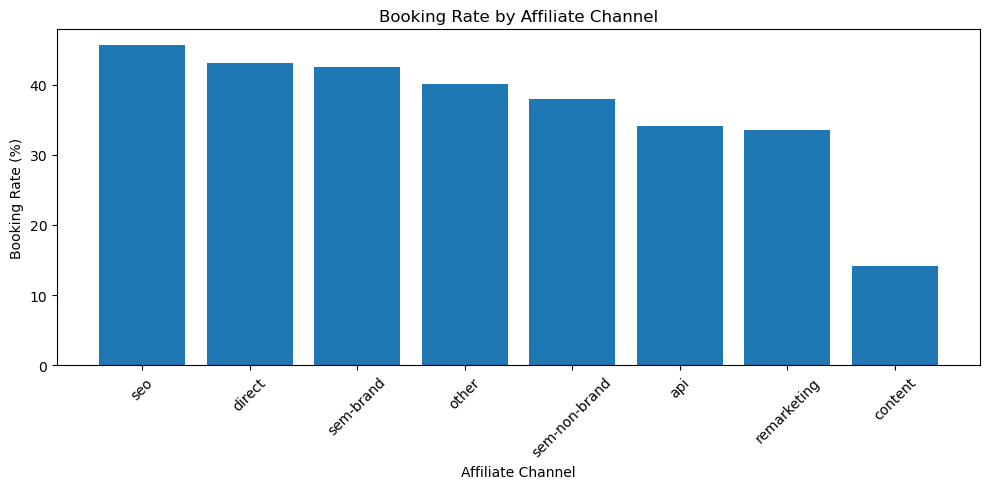

In [91]:
channel_rate_plot = channel_summary.sort_values("booking_rate", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(channel_rate_plot["affiliate_channel"], channel_rate_plot["booking_rate"])
plt.title("Booking Rate by Affiliate Channel")
plt.xlabel("Affiliate Channel")
plt.ylabel("Booking Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.3 Device Conversion Analysis

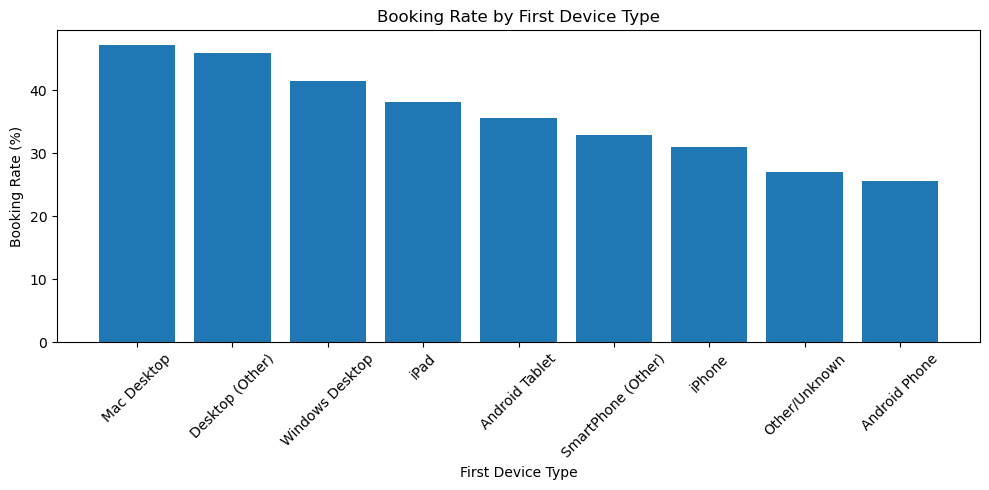

In [93]:
device_rate_plot = device_summary.sort_values("booking_rate", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(device_rate_plot["first_device_type"], device_rate_plot["booking_rate"])
plt.title("Booking Rate by First Device Type")
plt.xlabel("First Device Type")
plt.ylabel("Booking Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.4 Session Activity Analysis

C:\Users\XuefeiSun\AppData\Local\Temp\ipykernel_3024\1470740843.py:7: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\XuefeiSun\AppData\Local\Temp\ipykernel_3024\1470740843.py:7: UserWarning: Glyph 20197 (\N{CJK UNIFIED IDEOGRAPH-4EE5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\XuefeiSun\AppData\Local\Temp\ipykernel_3024\1470740843.py:7: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20197 (\N{CJK UNIFIED IDEOGRAPH-4EE5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:17

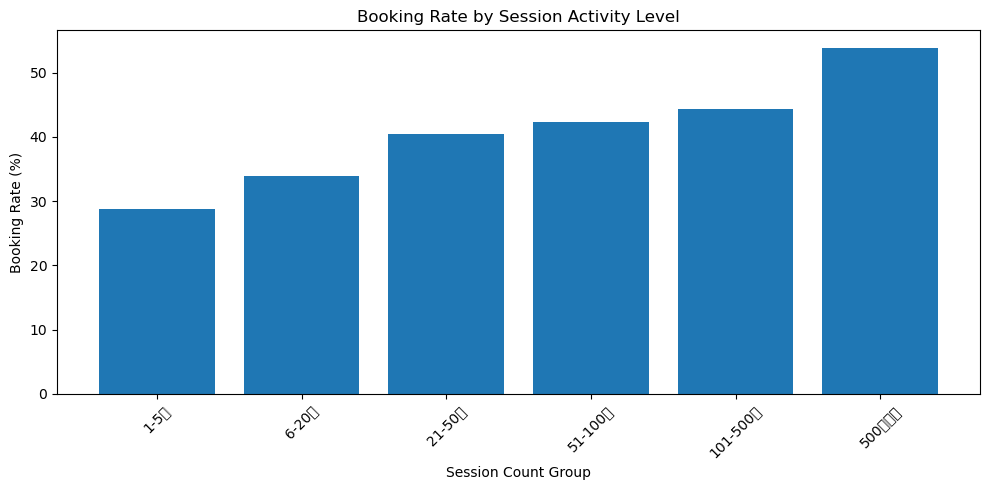

In [95]:
plt.figure(figsize=(10, 5))
plt.bar(session_group_summary["session_group"].astype(str), session_group_summary["booking_rate"])
plt.title("Booking Rate by Session Activity Level")
plt.xlabel("Session Count Group")
plt.ylabel("Booking Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Strict Behavior Funnel Analysis

In [101]:
# 构建行为阶段标记
user_features["has_session"] = user_features["session_count"] > 0
user_features["has_search"] = user_features["view_search_results_count"] > 0
user_features["has_listing_view"] = user_features["p3_view_count"] > 0
user_features["has_reservation_action"] = user_features["reservation_action_count"] > 0
user_features["has_payment_action"] = user_features["payment_action_count"] > 0

# 只基于有 session 的用户做行为漏斗
base = user_features[user_features["has_session"]].copy()

# 严格漏斗：后一层必须属于前一层
stage_1 = base
stage_2 = stage_1[stage_1["has_search"]]
stage_3 = stage_2[stage_2["has_listing_view"]]
stage_4 = stage_3[stage_3["has_reservation_action"]]
stage_5 = stage_4[stage_4["has_payment_action"]]

behavior_funnel = pd.DataFrame({
    "stage": [
        "Users with Sessions",
        "Search Result Viewers",
        "Listing Page Viewers after Search",
        "Reservation Action Users after Listing",
        "Payment Action Users after Reservation"
    ],
    "user_count": [
        stage_1["id"].nunique(),
        stage_2["id"].nunique(),
        stage_3["id"].nunique(),
        stage_4["id"].nunique(),
        stage_5["id"].nunique()
    ]
})

behavior_funnel["overall_rate"] = behavior_funnel["user_count"] / behavior_funnel.loc[0, "user_count"] * 100
behavior_funnel["step_conversion_rate"] = behavior_funnel["user_count"] / behavior_funnel["user_count"].shift(1) * 100
behavior_funnel.loc[0, "step_conversion_rate"] = 100

behavior_funnel

,stage,user_count,overall_rate,step_conversion_rate
0,Users with Sessions,73815,100.000000,100.000000
1,Search Result Viewers,43892,59.462169,59.462169
2,Listing Page Viewers after Search,39936,54.102825,90.986968
3,Reservation Action Users after Listing,3687,4.994920,9.232272
4,Payment Action Users after Reservation,2245,3.041387,60.889612


In [103]:
#各行为阶段的最终首单转化率
stage_conversion = pd.DataFrame({
    "stage": [
        "Users with Sessions",
        "Search Result Viewers",
        "Listing Page Viewers",
        "Reservation Action Users",
        "Payment Action Users"
    ],
    "user_count": [
        base["id"].nunique(),
        base[base["has_search"]]["id"].nunique(),
        base[base["has_listing_view"]]["id"].nunique(),
        base[base["has_reservation_action"]]["id"].nunique(),
        base[base["has_payment_action"]]["id"].nunique()
    ],
    "booking_rate": [
        base["is_booked"].mean() * 100,
        base[base["has_search"]]["is_booked"].mean() * 100,
        base[base["has_listing_view"]]["is_booked"].mean() * 100,
        base[base["has_reservation_action"]]["is_booked"].mean() * 100,
        base[base["has_payment_action"]]["is_booked"].mean() * 100
    ]
})

stage_conversion

,stage,user_count,booking_rate
0,Users with Sessions,73815,38.981237
1,Search Result Viewers,43892,38.749658
2,Listing Page Viewers,48500,40.575258
3,Reservation Action Users,4746,33.796882
4,Payment Action Users,3764,36.769394


## 7. High-Intent Unbooked User Analysis

In [105]:
# 高意向未转化用户：有较多行为、看过房源详情页，但最终没有完成首单
high_intent_unbooked = user_features[
    (user_features["has_session"] == True) &
    (user_features["p3_view_count"] > 0) &
    (user_features["session_count"] >= 50) &
    (user_features["is_booked"] == 0)
].copy()

print("高意向未转化用户数:", high_intent_unbooked["id"].nunique())
print("占有 session 用户比例:", round(high_intent_unbooked["id"].nunique() / base["id"].nunique() * 100, 2), "%")

高意向未转化用户数: 16935
占有 session 用户比例: 22.94 %


In [107]:
high_intent_channel = high_intent_unbooked.groupby("affiliate_channel").agg(
    user_count=("id", "count"),
    avg_session_count=("session_count", "mean"),
    avg_listing_views=("p3_view_count", "mean"),
    avg_search_views=("view_search_results_count", "mean")
).reset_index().sort_values("user_count", ascending=False)

high_intent_channel

,affiliate_channel,user_count,avg_session_count,avg_listing_views,avg_search_views
2,direct,10806,149.540996,19.392467,26.059967
5,sem-brand,2948,144.919267,18.440638,27.014925
6,sem-non-brand,1417,146.460127,18.695131,29.269584
7,seo,707,140.079208,17.253182,25.070721
0,api,452,155.597345,13.696903,35.203540
1,content,295,131.579661,17.325424,34.762712
3,other,158,141.481013,15.506329,28.525316
4,remarketing,152,147.848684,18.585526,38.032895


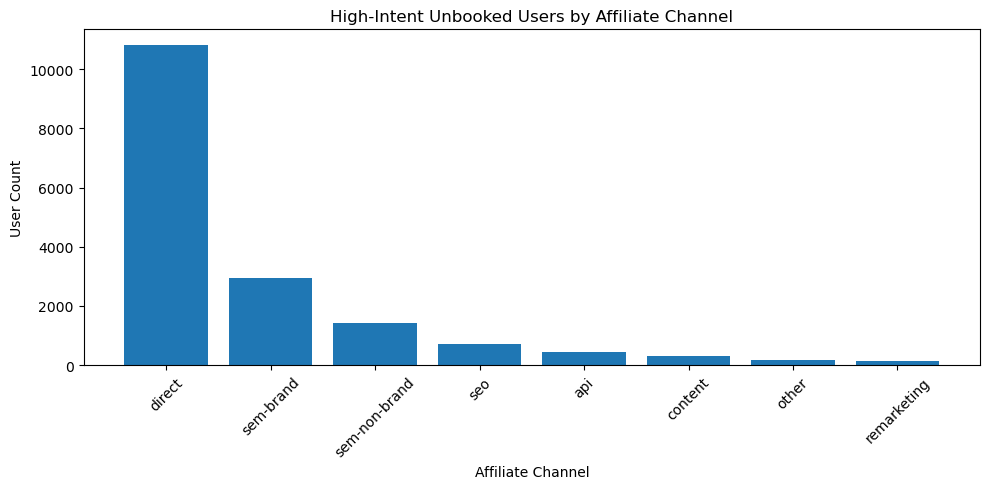

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(high_intent_channel["affiliate_channel"], high_intent_channel["user_count"])
plt.title("High-Intent Unbooked Users by Affiliate Channel")
plt.xlabel("Affiliate Channel")
plt.ylabel("User Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

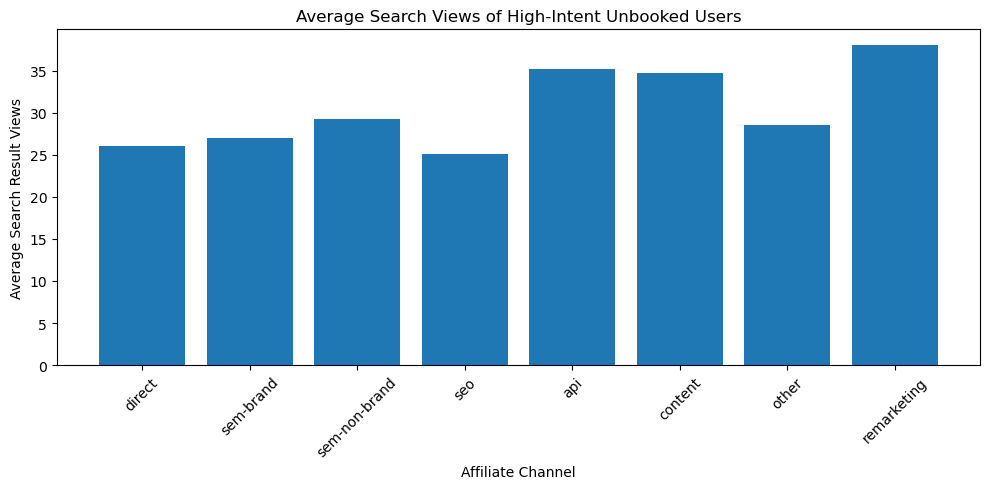

In [111]:
plt.figure(figsize=(10, 5))
plt.bar(high_intent_channel["affiliate_channel"], high_intent_channel["avg_search_views"])
plt.title("Average Search Views of High-Intent Unbooked Users")
plt.xlabel("Affiliate Channel")
plt.ylabel("Average Search Result Views")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

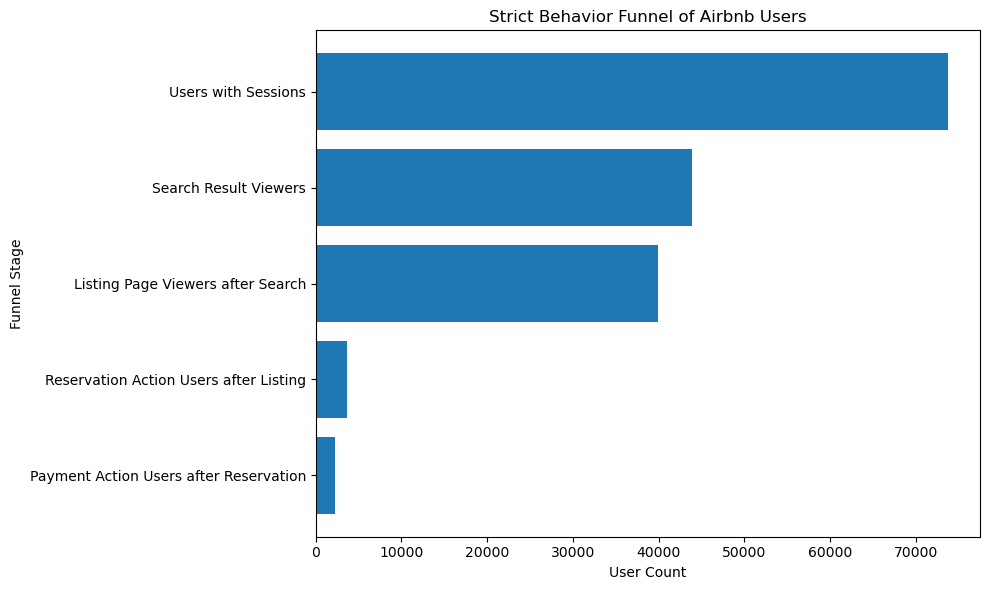

In [113]:
plt.figure(figsize=(10, 6))
plt.barh(behavior_funnel["stage"], behavior_funnel["user_count"])
plt.gca().invert_yaxis()
plt.title("Strict Behavior Funnel of Airbnb Users")
plt.xlabel("User Count")
plt.ylabel("Funnel Stage")
plt.tight_layout()
plt.show()

## 8. Booking Prediction Model

In [115]:
#用户预测
import pandas as pd
import numpy as np

user_features = pd.read_csv(r"D:\airbnb_user_features.csv")

print(user_features.shape)
user_features.head()

(213451, 36)


C:\Users\XuefeiSun\AppData\Local\Temp\ipykernel_3024\2928743487.py:5: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  user_features = pd.read_csv(r"D:\airbnb_user_features.csv")


,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,...,mean_secs_elapsed,max_secs_elapsed,unique_action_count,unique_action_type_count,unique_action_detail_count,unique_device_count,view_search_results_count,p3_view_count,reservation_action_count,payment_action_count
0,gxn3p5htnn,2010-06-28,2009-03-19 04:32:55,NaN,-unknown-,NaN,facebook,0,en,direct,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,820tgsjxq7,2011-05-25,2009-05-23 17:48:09,NaN,MALE,38.0,facebook,0,en,seo,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4ft3gnwmtx,2010-09-28,2009-06-09 23:12:47,2010-08-02,FEMALE,56.0,basic,3,en,direct,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,bjjt8pjhuk,2011-12-05,2009-10-31 06:01:29,2012-09-08,FEMALE,42.0,facebook,0,en,direct,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,87mebub9p4,2010-09-14,2009-12-08 06:11:05,2010-02-18,-unknown-,41.0,basic,0,en,direct,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [117]:
user_features["is_booked"].value_counts()

is_booked
0    124543
1     88908
Name: count, dtype: int64

In [119]:
user_features["is_booked"].value_counts(normalize=True)

is_booked
0    0.583473
1    0.416527
Name: proportion, dtype: float64

## 8. Booking Prediction Model

In [121]:
feature_cols = [
    # 用户基础信息
    "gender_clean",
    "age_group",
    "signup_method",
    "signup_flow",
    "language",
    
    # 渠道信息
    "affiliate_channel",
    "affiliate_provider",
    "first_affiliate_tracked",
    
    # 设备信息
    "signup_app",
    "first_device_type",
    "first_browser",
    
    # 时间信息
    "account_created_year",
    "account_created_month",
    
    # 行为强度特征
    "session_count",
    "total_secs_elapsed",
    "mean_secs_elapsed",
    "max_secs_elapsed",
    "unique_action_count",
    "unique_action_type_count",
    "unique_action_detail_count",
    "unique_device_count",
    "view_search_results_count",
    "p3_view_count"
]

target_col = "is_booked"

X = user_features[feature_cols].copy()
y = user_features[target_col].copy()

print(X.shape, y.shape)

(213451, 23) (213451,)


In [123]:
#区分数值变量和类别变量
numeric_features = [
    "signup_flow",
    "account_created_year",
    "account_created_month",
    "session_count",
    "total_secs_elapsed",
    "mean_secs_elapsed",
    "max_secs_elapsed",
    "unique_action_count",
    "unique_action_type_count",
    "unique_action_detail_count",
    "unique_device_count",
    "view_search_results_count",
    "p3_view_count"
]

categorical_features = [
    "gender_clean",
    "age_group",
    "signup_method",
    "language",
    "affiliate_channel",
    "affiliate_provider",
    "first_affiliate_tracked",
    "signup_app",
    "first_device_type",
    "first_browser"
]

In [125]:
#划分训练集和测试集
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train 分布：")
print(y_train.value_counts(normalize=True))

X_train: (170760, 23)
X_test: (42691, 23)
y_train 分布：
is_booked
0    0.583474
1    0.416526
Name: proportion, dtype: float64


### 8.2 Logistic Regression

In [127]:
#logistic
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

logit_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logit_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['signup_flow',
                                                   'account_created_year',
                                                   'account_created_month',
                                                   'session_count',
                                                   'total_secs_elapsed',
                                                   'mean_secs_elapsed',
                                                   'max_secs_elapsed',
                                                   'unique_action_count',
                                                   'unique_action_type_count',
                                                   '...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender_clean', 'age_group',
                                                   'signup_method', 'language',
                                                   'affiliate_channel',
                                                   'affiliate_provider',
                                                   'first_affiliate_tracked',
                                                   'signup_app',
                                                   'first_device_type',
                                                   'first_browser'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [129]:
y_pred = logit_model.predict(X_test)
y_proba = logit_model.predict_proba(X_test)[:, 1]

logit_results = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "auc": roc_auc_score(y_test, y_proba)
}

logit_results

{'accuracy': 0.6864912979316483,
 'precision': 0.6154330708661417,
 'recall': 0.6593184118771792,
 'f1': 0.6366203301476977,
 'auc': 0.742978191601571}

In [131]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.71      0.72     24909
           1       0.62      0.66      0.64     17782

    accuracy                           0.69     42691
   macro avg       0.68      0.68      0.68     42691
weighted avg       0.69      0.69      0.69     42691



In [133]:
confusion_matrix(y_test, y_pred)

array([[17583,  7326],
       [ 6058, 11724]], dtype=int64)

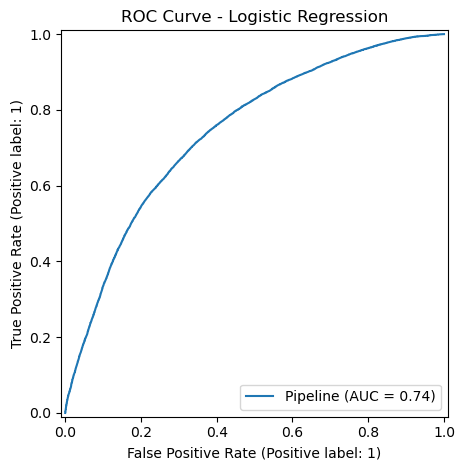

In [135]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(logit_model, X_test, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.tight_layout()
plt.show()

### 8.3 Random Forest

In [137]:
#RF
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=50,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['signup_flow',
                                                   'account_created_year',
                                                   'account_created_month',
                                                   'session_count',
                                                   'total_secs_elapsed',
                                                   'mean_secs_elapsed',
                                                   'max_secs_elapsed',
                                                   'unique_action_count',
                                                   'unique_action_type_count',
                                                   '...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender_clean', 'age_group',
                                                   'signup_method', 'language',
                                                   'affiliate_channel',
                                                   'affiliate_provider',
                                                   'first_affiliate_tracked',
                                                   'signup_app',
                                                   'first_device_type',
                                                   'first_browser'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        min_samples_leaf=50, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [139]:
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_results = {
    "accuracy": accuracy_score(y_test, rf_pred),
    "precision": precision_score(y_test, rf_pred),
    "recall": recall_score(y_test, rf_pred),
    "f1": f1_score(y_test, rf_pred),
    "auc": roc_auc_score(y_test, rf_proba)
}

rf_results

{'accuracy': 0.6887165913190134,
 'precision': 0.6014633485389097,
 'recall': 0.7489033854459566,
 'f1': 0.6671342333992937,
 'auc': 0.7633160612852581}

### 8.4 Model Comparison

In [141]:
model_compare = pd.DataFrame([
    {"model": "Logistic Regression", **logit_results},
    {"model": "Random Forest", **rf_results}
])

model_compare

,model,accuracy,precision,recall,f1,auc
0,Logistic Regression,0.686491,0.615433,0.659318,0.636620,0.742978
1,Random Forest,0.688717,0.601463,0.748903,0.667134,0.763316


### 8.5 Feature Importance

In [143]:
#提取logistic的importance
# 取出预处理后的特征名
preprocessor_fitted = logit_model.named_steps["preprocessor"]

num_feature_names = numeric_features

cat_feature_names = preprocessor_fitted.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([num_feature_names, cat_feature_names])

# 取 Logistic Regression 系数
coef = logit_model.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coef,
    "abs_coefficient": np.abs(coef)
}).sort_values("abs_coefficient", ascending=False)

feature_importance.head(30)

,feature,coefficient,abs_coefficient
23,age_group_UNKNOWN,-1.373338,1.373338
53,affiliate_channel_content,-1.085269,1.085269
70,affiliate_provider_meetup,-0.893330,0.893330
25,signup_method_facebook,-0.835648,0.835648
40,language_it,-0.571295,0.571295
52,affiliate_channel_api,0.557779,0.557779
108,first_browser_Chromium,0.469005,0.469005
85,signup_app_Android,-0.455921,0.455921
46,language_pt,-0.444268,0.444268
18,age_group_25-34,0.420398,0.420398


In [145]:
feature_importance.to_csv(
    r"D:\airbnb_logistic_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

In [147]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["model"]

num_feature_names = numeric_features

cat_feature_names = rf_preprocessor.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([num_feature_names, cat_feature_names])

rf_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_classifier.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance.head(30)

,feature,importance
23,age_group_UNKNOWN,0.249242
18,age_group_25-34,0.093055
16,gender_clean_UNKNOWN,0.089151
8,unique_action_type_count,0.060911
24,signup_method_basic,0.060713
25,signup_method_facebook,0.053041
19,age_group_35-44,0.034563
13,gender_clean_FEMALE,0.032928
0,signup_flow,0.029702
9,unique_action_detail_count,0.025014


#调整阈值
threshold = 0.4

rf_pred_04 = (rf_proba >= threshold).astype(int)

print(classification_report(y_test, rf_pred_04))